# EduPredict — Analyse des facteurs associés à la performance scolaire

**Évaluation 2 — Sprint Produit en Squad**

> Objectif : analyser le dataset **Students Performance in Exams**, identifier des associations entre les caractéristiques des élèves et leurs performances, puis construire un petit prototype de classification pour illustrer une utilisation possible des données.

### Question métier

**Quels facteurs observables dans les données sont associés aux performances des élèves aux examens, et comment ces informations peuvent-elles aider un établissement à mieux identifier les besoins d’accompagnement scolaire ?**

### Important
- Les résultats décrivent **des associations observées dans le dataset** et ne prouvent pas de causalité.
- Le dataset n'est pas nécessairement représentatif des élèves du Congo.
- Le modèle ML est un **prototype pédagogique**, pas un outil de décision scolaire définitive.


## 1. Organisation du notebook

1. Installation/importation des bibliothèques
2. Chargement et vérification du dataset
3. Exploration initiale
4. Nettoyage et contrôle qualité
5. Feature engineering : score moyen et catégorie de performance
6. Analyse descriptive
7. Analyses comparatives
8. Corrélations
9. Visualisations
10. Conclusions métier
11. Prototype Machine Learning
12. Limites et prochaines étapes


In [1]:
from IPython.display import display
# Installation (décommenter uniquement si nécessaire dans Google Colab)
# !pip install -q pandas numpy matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## 2. Chargement du dataset

### Structure attendue

Placez le fichier ici :

```text
EduPredict/
└── data/
    └── StudentsPerformance.csv
```

Dans Google Colab, vous pouvez téléverser le CSV avec le code ci-dessous.

Le notebook accepte aussi les noms de colonnes standards du dataset Kaggle :
`gender`, `race/ethnicity`, `parental level of education`, `lunch`, `test preparation course`, `math score`, `reading score`, `writing score`.


In [2]:
# Recherche automatique du fichier
possible_paths = [
    Path("data/StudentsPerformance.csv"),
    Path("StudentsPerformance.csv"),
    Path("/content/StudentsPerformance.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

# Si le fichier n'est pas trouvé, proposer l'upload dans Colab
if DATA_PATH is None:
    try:
        from google.colab import files
        print("StudentsPerformance.csv introuvable. Sélectionnez le fichier CSV.")
        uploaded = files.upload()
        if uploaded:
            uploaded_name = next(iter(uploaded))
            DATA_PATH = Path(uploaded_name)
    except ImportError:
        pass

if DATA_PATH is None or not DATA_PATH.exists():
    raise FileNotFoundError(
        "Fichier StudentsPerformance.csv introuvable. "
        "Placez-le dans data/ ou téléversez-le dans Google Colab."
    )

df = pd.read_csv(DATA_PATH)

print(f"Fichier chargé : {DATA_PATH}")
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
display(df.head())


Fichier chargé : data/StudentsPerformance.csv
Dimensions : 1000 lignes × 8 colonnes


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Vérification de la structure
print("Colonnes :")
for col in df.columns:
    print(" -", col)

print("\nTypes de données :")
display(df.dtypes.to_frame("dtype"))

print("\nValeurs manquantes :")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_count"))


Colonnes :
 - gender
 - race/ethnicity
 - parental level of education
 - lunch
 - test preparation course
 - math score
 - reading score
 - writing score

Types de données :


,dtype
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64



Valeurs manquantes :


,missing_count
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [4]:
# Contrôles qualité initiaux
print("Nombre de doublons :", df.duplicated().sum())

numeric_expected = ["math score", "reading score", "writing score"]
missing_expected = [c for c in numeric_expected if c not in df.columns]

if missing_expected:
    raise ValueError(f"Colonnes de notes absentes : {missing_expected}")

for col in numeric_expected:
    print(
        f"{col}: min={df[col].min()}, max={df[col].max()}, "
        f"moyenne={df[col].mean():.2f}"
    )

display(df.describe(include="all").T)


Nombre de doublons : 0
math score: min=0, max=100, moyenne=66.09
reading score: min=17, max=100, moyenne=69.17
writing score: min=10, max=100, moyenne=68.05


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,female,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race/ethnicity,1000,5,group C,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental level of education,1000,6,some college,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test preparation course,1000,2,none,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math score,"1,000.00",NaN,NaN,NaN,66.09,15.16,0.00,57.00,66.00,77.00,100.00
reading score,"1,000.00",NaN,NaN,NaN,69.17,14.60,17.00,59.00,70.00,79.00,100.00
writing score,"1,000.00",NaN,NaN,NaN,68.05,15.20,10.00,57.75,69.00,79.00,100.00


## 3. Nettoyage des données

Le nettoyage reste volontairement simple et traçable :

- suppression des doublons exacts ;
- conversion explicite des notes en valeurs numériques ;
- contrôle des valeurs de notes hors intervalle 0–100 ;
- conservation des variables catégorielles ;
- vérification finale des valeurs manquantes.

Aucune ligne ne sera supprimée uniquement parce qu'elle appartient à un groupe particulier.


In [5]:
df_clean = df.copy()

# Suppression des doublons exacts
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = len(df_clean)

print(f"Doublons supprimés : {before - after}")

# Conversion des scores en numérique
for col in numeric_expected:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Vérification des scores hors bornes
invalid_scores = (
    (df_clean[numeric_expected] < 0) |
    (df_clean[numeric_expected] > 100)
).any(axis=1)

print("Lignes avec au moins une note hors 0–100 :", invalid_scores.sum())

if invalid_scores.any():
    display(df_clean.loc[invalid_scores, numeric_expected].head())

# Valeurs manquantes après conversion
print("\nValeurs manquantes après nettoyage :")
display(df_clean.isna().sum().to_frame("missing_count"))

print("\nDimensions après nettoyage :", df_clean.shape)


Doublons supprimés : 0
Lignes avec au moins une note hors 0–100 : 0

Valeurs manquantes après nettoyage :


,missing_count
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0



Dimensions après nettoyage : (1000, 8)


## 4. Feature engineering

Nous créons :

### `average_score`
La moyenne des trois matières :

**(Math + Reading + Writing) / 3**

### `performance_category`
Une catégorie simple pour le prototype ML :

- **Faible** : score moyen < 60
- **Moyenne** : 60 à < 75
- **Bonne** : ≥ 75

Ces seuils sont des conventions analytiques pour le projet et ne constituent pas une norme scolaire officielle.


In [6]:
df_clean["average_score"] = df_clean[numeric_expected].mean(axis=1)

def classify_performance(score):
    if score < 60:
        return "Faible"
    elif score < 75:
        return "Moyenne"
    return "Bonne"

df_clean["performance_category"] = df_clean["average_score"].apply(classify_performance)

print("Résumé du score moyen :")
display(df_clean["average_score"].describe())

print("\nRépartition des catégories :")
display(
    df_clean["performance_category"]
    .value_counts()
    .rename_axis("category")
    .to_frame("count")
)


Résumé du score moyen :


count   1,000.00
mean       67.77
std        14.26
min         9.00
25%        58.33
50%        68.33
75%        77.67
max       100.00
Name: average_score, dtype: float64


Répartition des catégories :


,count
category,
Moyenne,391
Bonne,324
Faible,285


In [7]:
# Vue synthétique des indicateurs
summary = pd.DataFrame({
    "Indicateur": [
        "Nombre d'élèves",
        "Moyenne Math",
        "Moyenne Reading",
        "Moyenne Writing",
        "Moyenne générale",
        "Médiane générale",
        "Écart-type général"
    ],
    "Valeur": [
        len(df_clean),
        df_clean["math score"].mean(),
        df_clean["reading score"].mean(),
        df_clean["writing score"].mean(),
        df_clean["average_score"].mean(),
        df_clean["average_score"].median(),
        df_clean["average_score"].std()
    ]
})

display(summary)


,Indicateur,Valeur
0,Nombre d'élèves,"1,000.00"
1,Moyenne Math,66.09
2,Moyenne Reading,69.17
3,Moyenne Writing,68.05
4,Moyenne générale,67.77
5,Médiane générale,68.33
6,Écart-type général,14.26


## 5. Analyse descriptive

Cette section répond à la première question métier : **quelle est la distribution générale des performances ?**


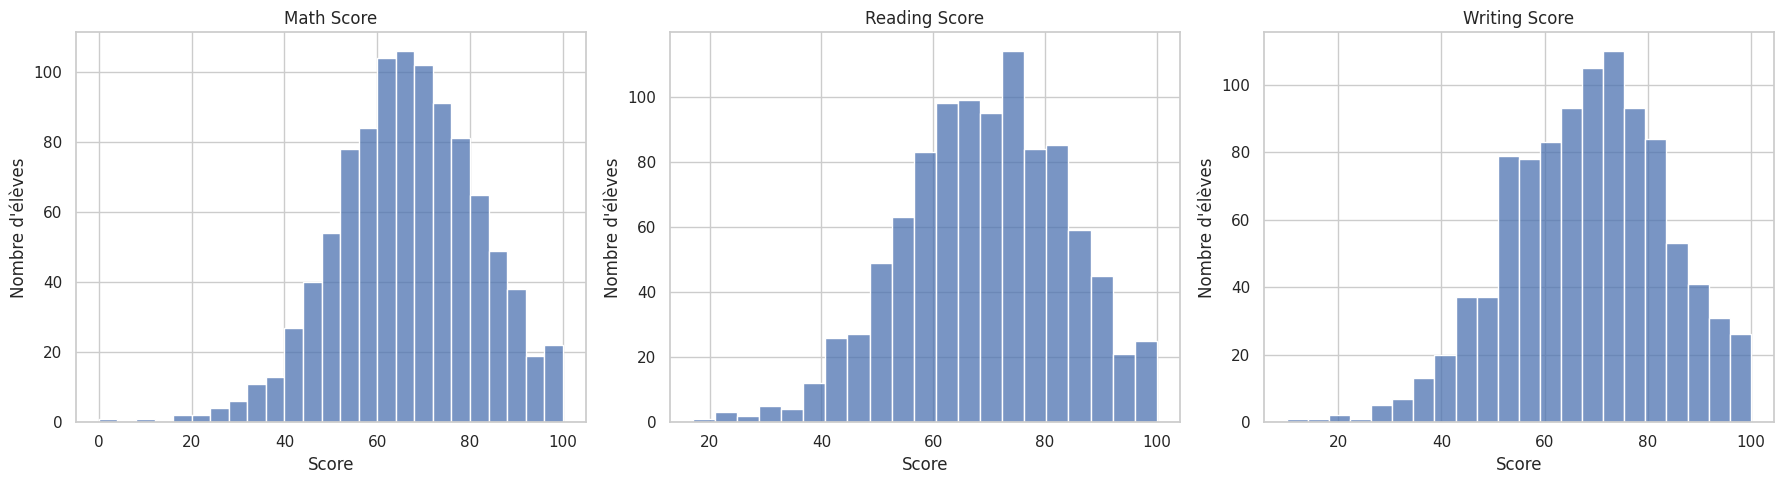

In [8]:
# Distribution des trois matières
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_expected):
    sns.histplot(df_clean[col], kde=False, ax=ax, color="C0")
    ax.set_title(col.title())
    ax.set_xlabel("Score")
    ax.set_ylabel("Nombre d'élèves")

plt.tight_layout()
plt.show()


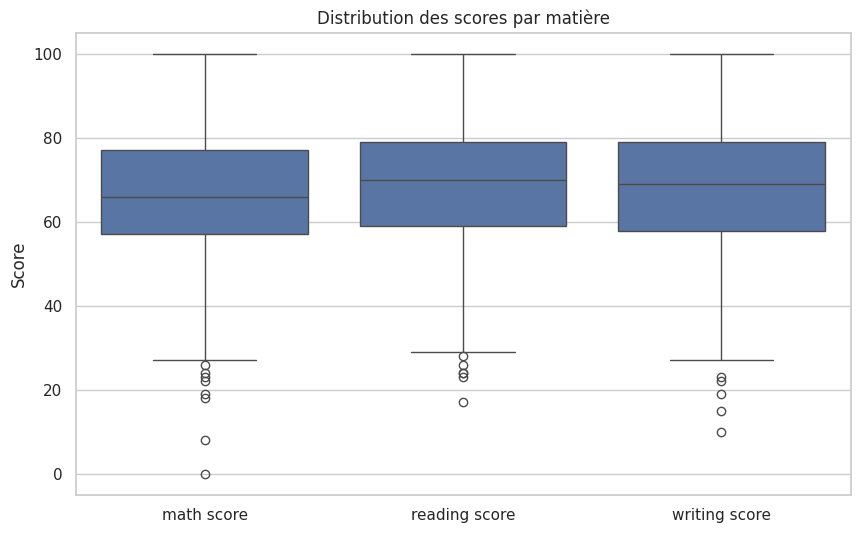

In [9]:
# Boxplot des trois matières
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[numeric_expected], color="C0")
plt.title("Distribution des scores par matière")
plt.ylabel("Score")
plt.show()


## 6. Performance selon le cours de préparation

Question :

**Les élèves ayant suivi le cours de préparation présentent-ils des scores moyens différents de ceux qui ne l'ont pas suivi ?**

Cette comparaison décrit une différence observée. Elle ne permet pas d'affirmer que le cours est la cause de cette différence.


In [10]:
prep_summary = (
    df_clean.groupby("test preparation course")
    .agg(
        students=("average_score", "size"),
        average_score=("average_score", "mean"),
        median_score=("average_score", "median"),
        math_mean=("math score", "mean"),
        reading_mean=("reading score", "mean"),
        writing_mean=("writing score", "mean")
    )
    .sort_values("average_score", ascending=False)
)

display(prep_summary)


,students,average_score,median_score,math_mean,reading_mean,writing_mean
test preparation course,,,,,,
completed,358,72.67,73.50,69.70,73.89,74.42
none,642,65.04,65.33,64.08,66.53,64.50


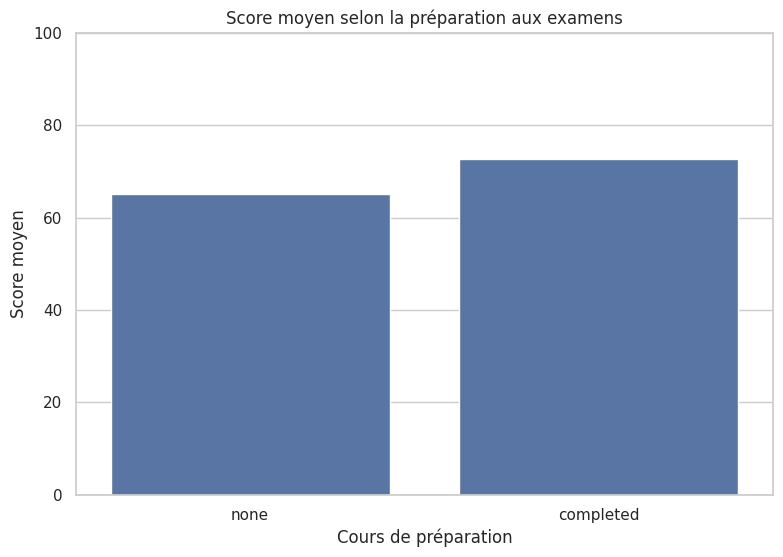

In [11]:
plt.figure(figsize=(9, 6))
sns.barplot(
    color="C0",
    data=df_clean,
    x="test preparation course",
    y="average_score",
    errorbar=None
)
plt.title("Score moyen selon la préparation aux examens")
plt.xlabel("Cours de préparation")
plt.ylabel("Score moyen")
plt.ylim(0, 100)
plt.show()


## 7. Performance selon le niveau d'éducation des parents

Question :

**Observe-t-on des différences de score moyen selon le niveau d'éducation des parents ?**


In [12]:
parent_education_summary = (
    df_clean.groupby("parental level of education")["average_score"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(parent_education_summary)


,count,mean,median
parental level of education,,,
master's degree,59,73.60,73.33
bachelor's degree,118,71.92,71.17
associate's degree,222,69.57,69.67
some college,226,68.48,68.67
some high school,179,65.11,66.67
high school,196,63.10,65.00


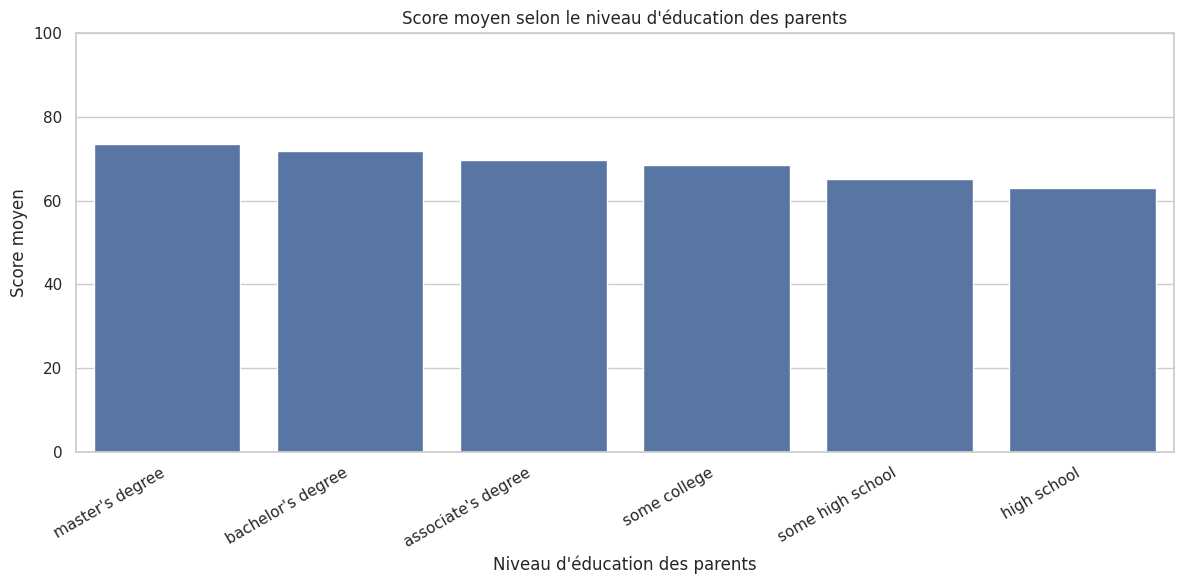

In [13]:
plt.figure(figsize=(12, 6))
order = (
    df_clean.groupby("parental level of education")["average_score"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    color="C0",
    data=df_clean,
    x="parental level of education",
    y="average_score",
    order=order,
    errorbar=None
)

plt.title("Score moyen selon le niveau d'éducation des parents")
plt.xlabel("Niveau d'éducation des parents")
plt.ylabel("Score moyen")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


## 8. Performance selon le type de repas

Question :

**Observe-t-on des différences de performance selon le type de repas indiqué dans les données ?**

Attention : cette variable doit être interprétée comme une variable observée dans le dataset, et non comme une preuve d'un mécanisme causal.


,count,mean,median
lunch,,,
standard,645,70.84,71.33
free/reduced,355,62.20,62.67


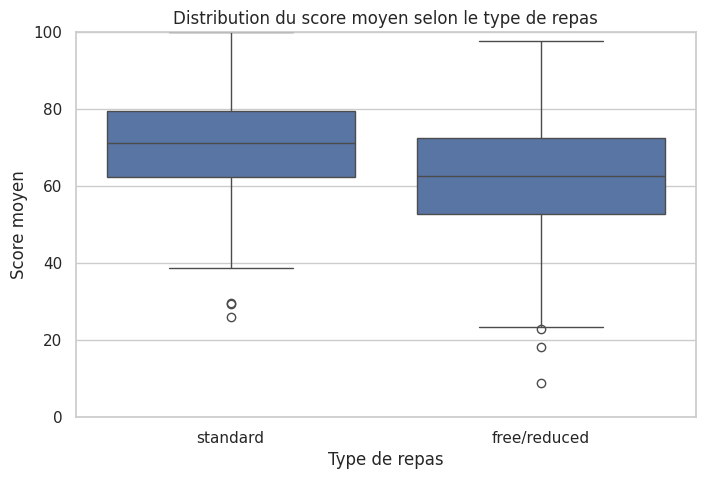

In [14]:
lunch_summary = (
    df_clean.groupby("lunch")["average_score"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(lunch_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="lunch", y="average_score", color="C0")
plt.title("Distribution du score moyen selon le type de repas")
plt.xlabel("Type de repas")
plt.ylabel("Score moyen")
plt.ylim(0, 100)
plt.show()


## 9. Performance selon le genre

Cette analyse permet de décrire les différences observées entre les catégories présentes dans le dataset.

Elle ne doit pas être utilisée pour généraliser les performances d'un groupe à une population extérieure au dataset.


,count,mean,median
gender,,,
female,518,69.57,70.33
male,482,65.84,66.33


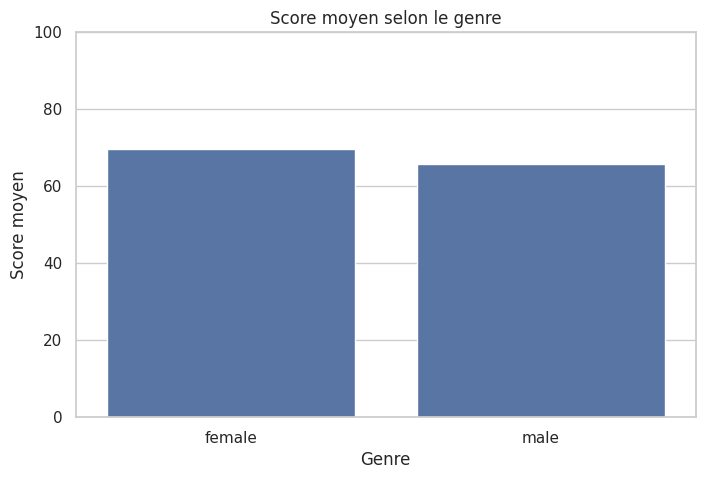

In [15]:
gender_summary = (
    df_clean.groupby("gender")["average_score"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(gender_summary)

plt.figure(figsize=(8, 5))
sns.barplot(
    color="C0",
    data=df_clean,
    x="gender",
    y="average_score",
    errorbar=None
)
plt.title("Score moyen selon le genre")
plt.xlabel("Genre")
plt.ylabel("Score moyen")
plt.ylim(0, 100)
plt.show()


## 10. Corrélations entre les matières

La matrice de corrélation permet de mesurer les relations linéaires entre les scores.

Une corrélation élevée indique que deux variables évoluent ensemble dans ce dataset ; elle ne démontre pas une causalité.


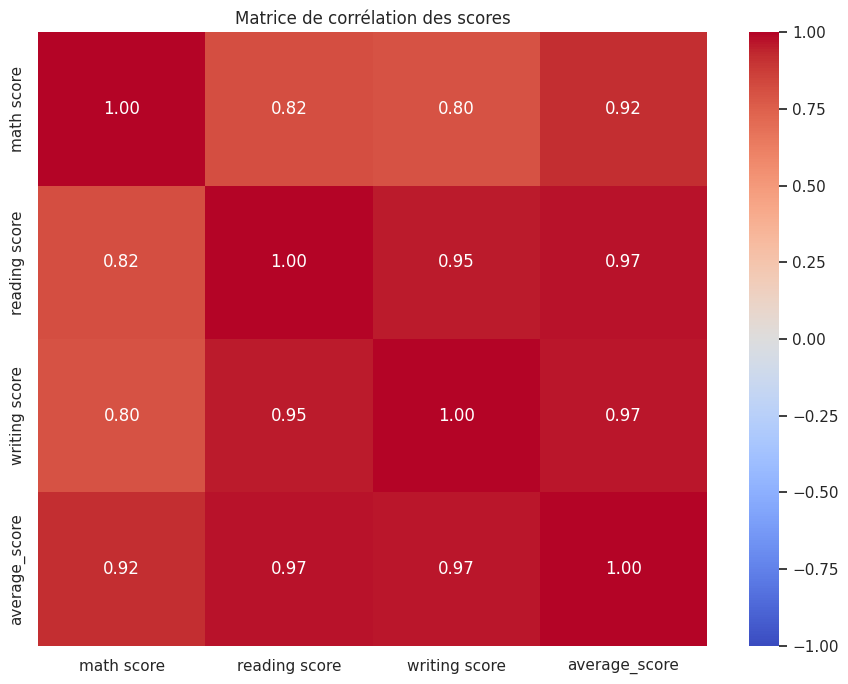

In [16]:
score_corr = df_clean[numeric_expected + ["average_score"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    score_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Matrice de corrélation des scores")
plt.tight_layout()
plt.show()


## 11. Analyse des catégories de performance

Nous allons examiner les profils associés aux catégories **Faible**, **Moyenne** et **Bonne**.


,students,average_score,math_mean,reading_mean,writing_mean
performance_category,,,,,
Faible,285,50.33,49.25,51.85,49.89
Moyenne,391,67.64,65.73,68.94,68.27
Bonne,324,83.27,81.34,84.69,83.77


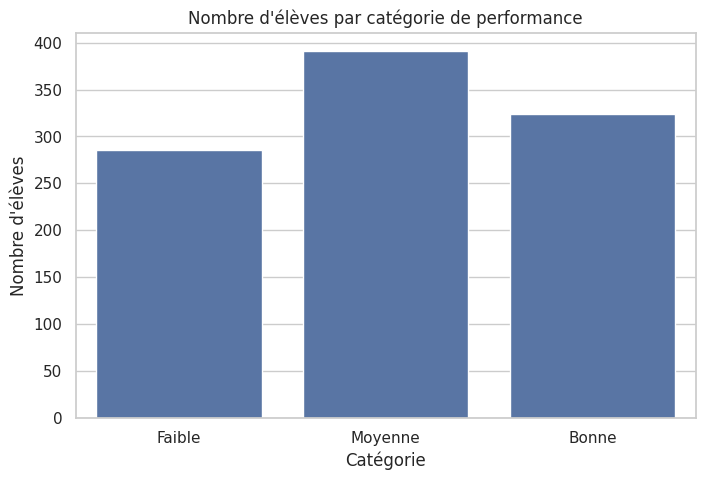

In [17]:
category_summary = (
    df_clean.groupby("performance_category")
    .agg(
        students=("average_score", "size"),
        average_score=("average_score", "mean"),
        math_mean=("math score", "mean"),
        reading_mean=("reading score", "mean"),
        writing_mean=("writing score", "mean")
    )
    .reindex(["Faible", "Moyenne", "Bonne"])
)

display(category_summary)

plt.figure(figsize=(8, 5))
sns.countplot(
    color="C0",
    data=df_clean,
    x="performance_category",
    order=["Faible", "Moyenne", "Bonne"]
)
plt.title("Nombre d'élèves par catégorie de performance")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'élèves")
plt.show()


## 12. Comparaison de plusieurs facteurs

Une vue croisée permet d'observer comment la préparation aux examens et le type de repas sont associés aux catégories de performance.


performance_category,Bonne,Faible,Moyenne
test preparation course,,,
completed,45.00,16.80,38.30
none,25.40,35.00,39.60


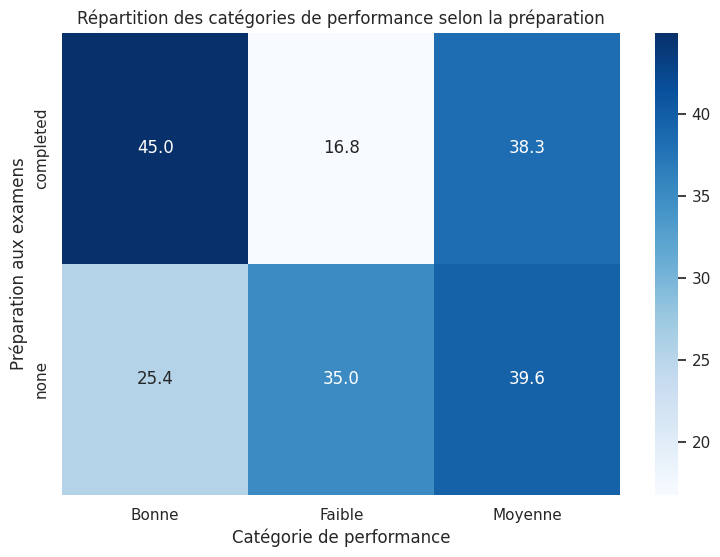

In [18]:
cross_tab = pd.crosstab(
    df_clean["test preparation course"],
    df_clean["performance_category"],
    normalize="index"
) * 100

display(cross_tab.round(1))

plt.figure(figsize=(9, 6))
sns.heatmap(cross_tab, annot=True, fmt=".1f", cmap="Blues")
plt.title("Répartition des catégories de performance selon la préparation")
plt.xlabel("Catégorie de performance")
plt.ylabel("Préparation aux examens")
plt.show()


# 13. Prototype Machine Learning

## Objectif

Construire un modèle capable de prédire la **catégorie de performance** à partir des caractéristiques disponibles **avant les notes** :

- gender
- race/ethnicity
- parental level of education
- lunch
- test preparation course

Nous n'utilisons volontairement pas les trois notes pour éviter une fuite de cible : la catégorie est elle-même construite à partir de ces notes.

### Modèles testés

- Régression logistique
- Random Forest

Le modèle est évalué sur un jeu de test séparé.

**Attention :** ce prototype sert à démontrer une démarche ML et ne doit pas être utilisé pour décider du parcours réel d'un élève.


In [19]:
feature_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

target_col = "performance_category"

model_df = df_clean[feature_cols + [target_col]].dropna().copy()

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

categorical_features = feature_cols

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append({
        "model": name,
        "accuracy": accuracy
    })

    print("=" * 70)
    print(name)
    print(f"Accuracy : {accuracy:.3f}")
    print()
    print(classification_report(y_test, predictions, zero_division=0))

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
display(results_df)


Logistic Regression
Accuracy : 0.445

              precision    recall  f1-score   support

       Bonne       0.47      0.52      0.49        65
      Faible       0.53      0.33      0.41        57
     Moyenne       0.40      0.46      0.43        78

    accuracy                           0.45       200
   macro avg       0.46      0.44      0.44       200
weighted avg       0.46      0.45      0.44       200



Random Forest
Accuracy : 0.330

              precision    recall  f1-score   support

       Bonne       0.37      0.45      0.41        65
      Faible       0.36      0.42      0.39        57
     Moyenne       0.24      0.17      0.20        78

    accuracy                           0.33       200
   macro avg       0.32      0.34      0.33       200
weighted avg       0.32      0.33      0.32       200



,model,accuracy
0,Logistic Regression,0.45
1,Random Forest,0.33


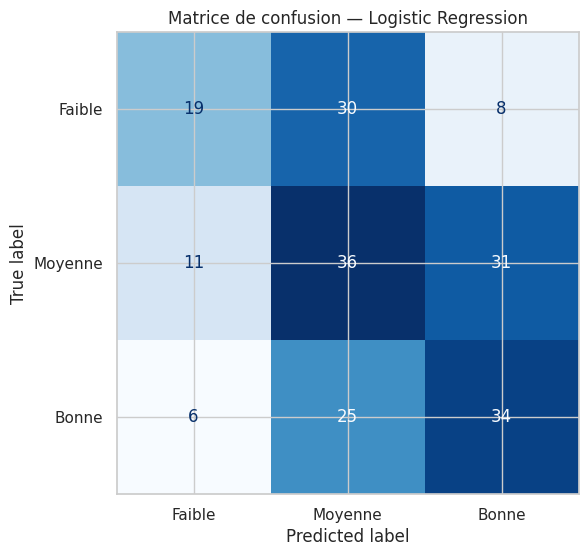

In [20]:
# Matrice de confusion du meilleur modèle
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)
best_predictions = best_pipeline.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=["Faible", "Moyenne", "Bonne"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Faible", "Moyenne", "Bonne"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion — {best_model_name}")
plt.show()


## 14. Tester une prédiction individuelle

Cette cellule permet de montrer au jury le fonctionnement du prototype.

**Important :** le résultat est une estimation statistique issue de ce dataset. Il ne constitue pas une évaluation définitive d'un élève.


In [21]:
# Exemple de profil fictif pour la démonstration
example_student = pd.DataFrame([{
    "gender": "female",
    "race/ethnicity": "group B",
    "parental level of education": "bachelor's degree",
    "lunch": "standard",
    "test preparation course": "completed"
}])

prediction = best_pipeline.predict(example_student)[0]

print("Profil de démonstration :")
display(example_student)

print(f"Catégorie de performance estimée : {prediction}")


Profil de démonstration :


,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,female,group B,bachelor's degree,standard,completed


Catégorie de performance estimée : Bonne


# 15. Synthèse métier

À compléter après exécution du notebook avec les valeurs réellement obtenues.

### Principaux constats à documenter

1. **Performance générale**
   - Moyenne globale des trois matières.
   - Matière présentant la moyenne la plus élevée/faible.
   - Dispersion des résultats.

2. **Préparation aux examens**
   - Comparaison des scores moyens.
   - Répartition des catégories.

3. **Éducation des parents**
   - Différences observées entre les catégories.

4. **Autres facteurs**
   - Type de repas.
   - Genre.
   - Groupe indiqué dans le dataset.

5. **Relations entre matières**
   - Corrélations principales.

6. **Prototype ML**
   - Accuracy des modèles.
   - Matrice de confusion.
   - Limites du modèle.

### Formulation recommandée

Les résultats doivent utiliser des formulations prudentes comme :

> « Dans le dataset étudié, on observe une différence de score moyen entre... »

plutôt que :

> « Cette variable provoque une meilleure réussite. »



# 18. Checklist avant dépôt

- [ ] `StudentsPerformance.csv` est présent dans le dossier `data/`
- [ ] Toutes les cellules s'exécutent sans erreur
- [ ] Les dimensions du dataset sont vérifiées
- [ ] Les doublons et valeurs manquantes sont contrôlés
- [ ] Le score moyen est créé
- [ ] Les graphiques sont lisibles
- [ ] Les résultats sont interprétés
- [ ] Les conclusions ne confondent pas corrélation et causalité
- [ ] Le modèle ML est présenté comme un prototype
- [ ] Le rapport PDF reprend les mêmes résultats que le notebook
- [ ] Le README explique comment exécuter le projet
- [ ] Le dépôt GitHub est propre et organisé
